In [1]:
!pip install langgraph langsmith langchain langchain_groq langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [2]:
from typing import Annotated
from typing_extensions import TypedDict

In [3]:
!pip install arxiv wikipedia

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.7 MB/s eta 0:00:00
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=3ce3442184387ec6749123947785a0b81eabb987cb7eadea1145a22fd699c8f5
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=8fab463a23693318c20d59a9c5816007f8e6336618d7bbeb87f19bef6900b082
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built wikipedia sgmllib3k


## Working with Tools

In [5]:
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun

# Arxiv and Wikipedia tools
arxiv_wrapper= ArxivAPIWrapper(top_k_results = 1, doc_content_chars_max=300)
arxiv_tool = ArxivQueryRun(api_wrapper=arxiv_wrapper)

api_wrapper = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=300)
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [6]:
wiki_tool.invoke("who is Alan Turing?")

'Page: Alan Turing law\nSummary: "Alan Turing law" is an informal term for the portion of the Policing and Crime Act 2017 which serves to pardon men who were cautioned or convicted under obsolete laws criminalising homosexual acts. The provision is named after Alan Turing, the World War II codebreaker'

In [7]:
arxiv_tool.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their mult'

In [8]:
tools= [wiki_tool]

## Langgraph Applications

In [10]:
from langgraph.graph.message import add_messages
class State(TypedDict):
  messages: Annotated[list,add_messages]

In [30]:
from langgraph.graph import StateGraph,START,END

In [31]:
graph_builder = StateGraph(State)

In [32]:
from langchain_groq import ChatGroq

In [33]:
from google.colab import userdata
groq_api_key = userdata.get("GROQ_API_KEY")

In [34]:
llm = ChatGroq(groq_api_key = groq_api_key, model_name = "openai/gpt-oss-120b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7ba31d53c5f0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7ba31d546540>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [35]:
llm_with_tools = llm.bind_tools(tools= tools)

In [36]:
def chatbot(state:State):
  return{"messages":[llm_with_tools.invoke(state["messages"])]}

In [37]:
from langgraph.prebuilt import ToolNode, tools_condition

In [38]:
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
tool_node=ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("chatbot", END)

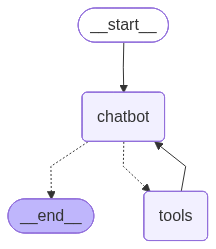

In [40]:
graph= graph_builder.compile()
graph

In [41]:
user_input = "Hi there!, My name is Sanaz"
events= graph.stream(
    {"messages":[("user", user_input)]}, stream_mode= "values"
)

for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there!, My name is Sanaz
================================== Ai Message ==================================

Hello Sanaz! 👋 Nice to meet you. How can I assist you today?
